# Simple Spread Strategy x Binance TH Fee Tiers — Year-to-Date Edition

**The 30-day notebook (`vip_fee_strategy_1m_30d.ipynb` / `usdthb_fee_tiers_simple.ipynb`),
re-run on the whole of this year.** Binance TH `USDTTHB` (1m candles) vs the real TFEX USD
futures price (Settrade `get_candlestick`), one strategy, five fee tiers, and the question
that matters:

> *enter when the gap pays more than ALL costs, exit when the gap is gone —
> and what RETURN (%) does that make at each VIP tier?*

No z-score. No statistics. Only three ideas a beginner needs:

```text
spread    = Binance price - TFEX price            (should be ~0, drifts a little)
fair      = typical spread of the last 4 hours    (a rolling median - just "what is normal")
deviation = spread - fair                          (how far from normal RIGHT NOW, in THB)
```

When the deviation is bigger than all round-trip costs -> trade. That is the whole strategy.

**One thing the year-to-date window forces us to admit up front:** the Settrade API only
serves contracts that are *still listed* — expired USD futures (`USDF26`, `USDG26`, ...)
return *Symbol not found*, and the current contract only has bars since it started trading
(**10 Mar 2026** for `USDM26`). So Binance data covers the full year, but the strategy can
only run where a real TFEX print exists. That is not a bug; it is what this data source
honestly offers.

> No orders are placed. `.env` needs Settrade credentials (a handful of API requests).

## Step 0 — The official Binance TH fee schedule

Source: [Binance TH FAQ](https://www.binance.th/en/faq/spot-trading/4900a0792af24f5e853e2373b84f94e7).
`USDTTHB` is an **exchange pair**, so the right-hand column applies. Maker = your resting
limit order gets hit (cheaper, but no guaranteed fill). Taker = you cross the book now.

| VIP | 30-day volume (USD) | Broker pairs maker/taker | **Exchange pairs maker/taker** |
|---|---|---|---|
| VIP 0 | < 150,000 | 0.10% / 0.10% | **0.25% / 0.25%** |
| VIP 1 | ≥ 150,000 | 0.10% / 0.10% | 0.20% / 0.25% |
| VIP 2 | ≥ 500,000 | 0.09% / 0.10% | 0.15% / 0.20% |
| VIP 3 | ≥ 1,500,000 | 0.08% / 0.10% | 0.10% / 0.15% |
| VIP 4 | ≥ 3,000,000 | 0.07% / 0.09% | 0.10% / 0.10% |

One more fact people confuse: TFEX's *"minimum price fluctuation THB 0.01 (= THB 10 per
contract)"* is the **tick size** (the smallest price step), **not a fee**. Fees are the
percentages above plus your TFEX commission.

In [1]:
import calendar as cal_module
import os
import time
from datetime import date, datetime, timedelta, timezone

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv
from settrade_v2 import Investor

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 120

# ---------- data: from 1 January of this year to today ----------
BINANCE_SYMBOL = "USDTTHB"
YEAR = date.today().year
intraday_start = f"{YEAR}-01-01"
intraday_end = date.today().strftime("%Y-%m-%d")
TFEX_INTERVAL = "60m"            # the API caps each request's range -> we walk month by month
MAX_REF_AGE_MIN = 75             # trust the spread only when TFEX traded recently
FAIR_WINDOW_MIN = 240            # "normal spread" = rolling 4-hour median

# ---------- costs ----------
TFEX_COST_PER_SIDE_THB = 0.025   # 25 THB per contract per side (brokerage+exchange+VAT) / 1,000 USD
BINANCE_BOOK_WIDTH_THB = 0.01    # crossing the Binance book as taker
TFEX_BOOK_WIDTH_THB = 0.02      # crossing the TFEX book (always, both styles)
ENTRY_BUFFER_THB = 0.01
EXIT_TOLERANCE_THB = 0.01

# ---------- fee scenarios (exchange-pair rates) ----------
FEE_SCENARIOS = {
    "VIP0_taker": {"fee": 0.0025, "maker": False},
    "VIP2_taker": {"fee": 0.0020, "maker": False},
    "VIP2_maker": {"fee": 0.0015, "maker": True},
    "VIP4_taker": {"fee": 0.0010, "maker": False},
    "VIP4_maker": {"fee": 0.0010, "maker": True},
}
VIP_VOLUME_REQ_USD = {"VIP2": 500_000, "VIP4": 3_000_000}

# ---------- active TFEX USD contract ----------
TFEX_MONTH_CODES = {1: "F", 2: "G", 3: "H", 4: "J", 5: "K", 6: "M",
                    7: "N", 8: "Q", 9: "U", 10: "V", 11: "X", 12: "Z"}


def _last_biz_day(year, month):
    d = date(year, month, cal_module.monthrange(year, month)[1])
    while d.weekday() >= 5:
        d -= timedelta(days=1)
    return d


def _prev_biz_day(d):
    d -= timedelta(days=1)
    while d.weekday() >= 5:
        d -= timedelta(days=1)
    return d


def active_usd_contract(today=None):
    today = today or date.today()
    year, month = today.year, today.month
    ltd = _prev_biz_day(_last_biz_day(year, month))
    if today > ltd:
        month += 1
        if month > 12:
            month, year = 1, year + 1
        ltd = _prev_biz_day(_last_biz_day(year, month))
    return f"USD{TFEX_MONTH_CODES[month]}{str(year)[-2:]}", ltd


CONTRACT, _ = active_usd_contract()
print(f"Window: {intraday_start} -> {intraday_end} | TFEX contract: {CONTRACT}")

Window: 2026-01-01 -> 2026-06-12 | TFEX contract: USDM26


## Step 1 — Fetch the data

Binance TH 1m candles (public; ~230 requests for the year, 1,000 candles each) and the
TFEX reference via the official Settrade
[`get_candlestick`](https://developer.settrade.com/open-api/api-reference/reference/sdkv2/python/market-historical-data/2_getCandlestick).
One request cannot cover the whole year (*"Too many data requested"*), so we ask month by
month — still one symbol, one official endpoint.

Why only the current contract? TFEX USD futures expire monthly, and the API **deletes
expired symbols** — `USDF26` (January) is simply gone. The current contract `USDM26` is the
only queryable series that overlaps this year, and its history starts the day it first
traded. The fetch below prints exactly how much of the year that gives us.

In [2]:
def _interval_to_ms(interval):
    units = {"m": 60_000, "h": 3_600_000, "d": 86_400_000, "w": 604_800_000}
    return int(interval[:-1]) * units[interval[-1]]


def fetch_ohlcv_binanceth(start, end, interval="1m"):
    chunk_ms = min(7 * 24 * 3_600_000, 1000 * _interval_to_ms(interval))
    start_ms = int(datetime.strptime(start, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp() * 1000)
    end_ms = int(datetime.strptime(end, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp() * 1000)
    all_rows, cursor, n_req = [], start_ms, 0
    while cursor < end_ms:
        chunk_end = min(cursor + chunk_ms, end_ms)
        resp = requests.get("https://api.binance.th/api/v1/klines",
                            params={"symbol": BINANCE_SYMBOL, "interval": interval,
                                    "startTime": cursor, "endTime": chunk_end, "limit": 1000},
                            timeout=20)
        resp.raise_for_status()
        rows = resp.json()
        if isinstance(rows, dict):
            raise ValueError(f"Binance TH API error: {rows}")
        all_rows.extend(rows)
        n_req += 1
        if n_req % 50 == 0:
            print(f"  Binance TH request {n_req} ... ({pd.to_datetime(cursor, unit='ms'):%d %b})")
        cursor = chunk_end + 1
        time.sleep(0.05)
    df = pd.DataFrame(all_rows, columns=[
        "OpenTime", "Open", "High", "Low", "Close", "Volume",
        "CloseTime", "QuoteVol", "TradeCount", "TakerBase", "TakerQuote", "_"])
    df["OpenTime"] = pd.to_datetime(df["OpenTime"], unit="ms", utc=True)
    df = df.set_index("OpenTime")
    df.index = df.index.tz_convert("Asia/Bangkok").tz_localize(None)
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        df[col] = df[col].astype(float)
    df = df[~df.index.duplicated(keep="last")].sort_index()
    print(f"Binance TH requests: {n_req}")
    return df


def month_chunks(start, end):
    chunks, cur = [], date.fromisoformat(start)
    last = date.fromisoformat(end)
    while cur <= last:
        month_end = date(cur.year, cur.month, cal_module.monthrange(cur.year, cur.month)[1])
        chunks.append((cur, min(month_end, last)))
        cur = month_end + timedelta(days=1)
    return chunks


load_dotenv()
investor = Investor(
    app_id=os.environ["SETTRADE_APP_ID"],
    app_secret=os.environ["SETTRADE_APP_SECRET"],
    app_code=os.environ["SETTRADE_APP_CODE"],
    broker_id=os.environ["SETTRADE_BROKER_ID"],
    is_auto_queue=False,
)
mkt = investor.MarketData()
parts = []
for s, e in month_chunks(intraday_start, intraday_end):
    res = mkt.get_candlestick(symbol=CONTRACT, interval=TFEX_INTERVAL,
                              start=f"{s}T00:00", end=f"{e}T23:59")
    print(f"  TFEX {CONTRACT} {s:%b %Y}: {len(res['close']):4d} bars")
    if res["close"]:
        idx = pd.to_datetime(res["time"], unit="s", utc=True).tz_convert("Asia/Bangkok").tz_localize(None)
        parts.append(pd.DataFrame({"Close": res["close"], "Volume": res["volume"]}, index=idx).astype(float))
tfex = pd.concat(parts).sort_index()
tfex = tfex[~tfex.index.duplicated(keep="last")]
print(f"TFEX history starts {tfex.index.min():%d %b %Y} - earlier months are unreachable through this API")

intra_ohlcv = fetch_ohlcv_binanceth(intraday_start, intraday_end)
print(f"Binance {BINANCE_SYMBOL}: {len(intra_ohlcv):,} x 1m | TFEX {CONTRACT}: {len(tfex):,} x {TFEX_INTERVAL}")

  TFEX USDM26 Jan 2026:    0 bars
  TFEX USDM26 Feb 2026:    0 bars
  TFEX USDM26 Mar 2026:  269 bars


  TFEX USDM26 Apr 2026:  306 bars
  TFEX USDM26 May 2026:  326 bars


  TFEX USDM26 Jun 2026:  133 bars
TFEX history starts 10 Mar 2026 - earlier months are unreachable through this API


  Binance TH request 50 ... (04 Feb)


  Binance TH request 100 ... (10 Mar)


  Binance TH request 150 ... (14 Apr)


  Binance TH request 200 ... (19 May)


Binance TH requests: 234
Binance USDTTHB: 233,280 x 1m | TFEX USDM26: 1,034 x 60m


## Step 2 — Build the spread and the deviation (plain words, no statistics)

1. Put the TFEX price next to every Binance minute (carry the last TFEX bar forward, and
   **only trust minutes where that bar is fresher than 75 minutes** — Binance trades 24/7,
   TFEX does not). Minutes before the contract's first trade have no reference at all and
   are dropped.
2. `fair` = the *typical* spread of the last 4 hours (a rolling **median** — literally
   "the middle value", nothing fancier). A bonus on this long window: the futures price
   carries a small premium vs spot that shrinks toward expiry, and the rolling median
   absorbs that drift automatically.
3. `deviation` = how far the spread is from typical, in THB per USD. **This number is the
   whole strategy**: when it is bigger than all costs, the gap pays.

In [3]:
df = intra_ohlcv[["Close", "Volume"]].copy()
ref = tfex["Close"]
df["TFEX_REF"] = ref.reindex(df.index, method="ffill")
ref_times = pd.Series(ref.index, index=ref.index).reindex(df.index, method="ffill")
df["ref_age_min"] = (df.index - ref_times).dt.total_seconds() / 60
df = df.dropna(subset=["TFEX_REF"])
df["ref_fresh"] = df["ref_age_min"] <= MAX_REF_AGE_MIN

df["spread"] = df["Close"] - df["TFEX_REF"]
df["fair"] = df["spread"].rolling(FAIR_WINDOW_MIN, min_periods=60).median()
df["dev"] = df["spread"] - df["fair"]

fresh = df[df.ref_fresh].dropna(subset=["dev"]).copy()
avg_price = df["Close"].mean()

print(f"Minutes with a TFEX reference: {len(df):,} | trusted (fresh TFEX) minutes: {len(fresh):,} "
      f"({len(fresh) / len(df):.0%})")
print(f"Deviation on trusted minutes: typical size {fresh.dev.abs().median():.3f} THB | "
      f"biggest {fresh.dev.abs().max():.3f} THB")
print("\nTrusted minutes per month (how much of the year the strategy can actually see):")
print(fresh.groupby(fresh.index.to_period("M")).size().to_string())

Minutes with a TFEX reference: 135,241 | trusted (fresh TFEX) minutes: 63,061 (47%)
Deviation on trusted minutes: typical size 0.020 THB | biggest 0.600 THB

Trusted minutes per month (how much of the year the strategy can actually see):
OpenTime
2026-03    16577
2026-04    18936
2026-05    20184
2026-06     7364
Freq: M


## Step 3 — Turn each fee tier into ONE number: the entry bar

Per 1 USD of position, a full round trip (open + close) costs:

```text
round_trip = 2 x binance_fee x price        (Binance, entry + exit)
           + 2 x 0.025                       (TFEX commission, entry + exit)
           + TFEX book width (0.02)          (you cross the TFEX book)
           + Binance book width (0.01)       (taker only - maker posts and waits)
entry bar  = round_trip + 0.01 buffer
```

In [4]:
cost_rows = []
for name, sc in FEE_SCENARIOS.items():
    rt = (2 * sc["fee"] * avg_price + 2 * TFEX_COST_PER_SIDE_THB
          + TFEX_BOOK_WIDTH_THB + (0 if sc["maker"] else BINANCE_BOOK_WIDTH_THB))
    sc["round_trip"] = rt
    sc["bar"] = rt + ENTRY_BUFFER_THB
    cost_rows.append({"scenario": name, "fee_per_side": f"{sc['fee']:.2%}",
                      "round_trip_thb_per_usd": round(rt, 4),
                      "entry_bar_thb_per_usd": round(sc["bar"], 4),
                      "entry_bar_thb_per_contract": round(sc["bar"] * 1000),
                      "minutes_beyond_bar": int((fresh.dev.abs() >= sc["bar"]).sum())})
display(pd.DataFrame(cost_rows).set_index("scenario"))
print(f"Average price: {avg_price:.2f} THB/USD. "
      f"Biggest deviation seen: {fresh.dev.abs().max():.3f} THB/USD.")

,fee_per_side,round_trip_thb_per_usd,entry_bar_thb_per_usd,entry_bar_thb_per_contract,minutes_beyond_bar
scenario,,,,,
VIP0_taker,0.25%,0.2423,0.2523,252,236
VIP2_taker,0.20%,0.2098,0.2198,220,323
VIP2_maker,0.15%,0.1674,0.1774,177,432
VIP4_taker,0.10%,0.1449,0.1549,155,608
VIP4_maker,0.10%,0.1349,0.1449,145,782


Average price: 32.45 THB/USD. Biggest deviation seen: 0.600 THB/USD.


## Step 4 — Look at the data with the entry bars drawn on top

If the green line never escapes a tier's dashed band, that tier can never trade.
This one picture is the whole economics of the strategy.

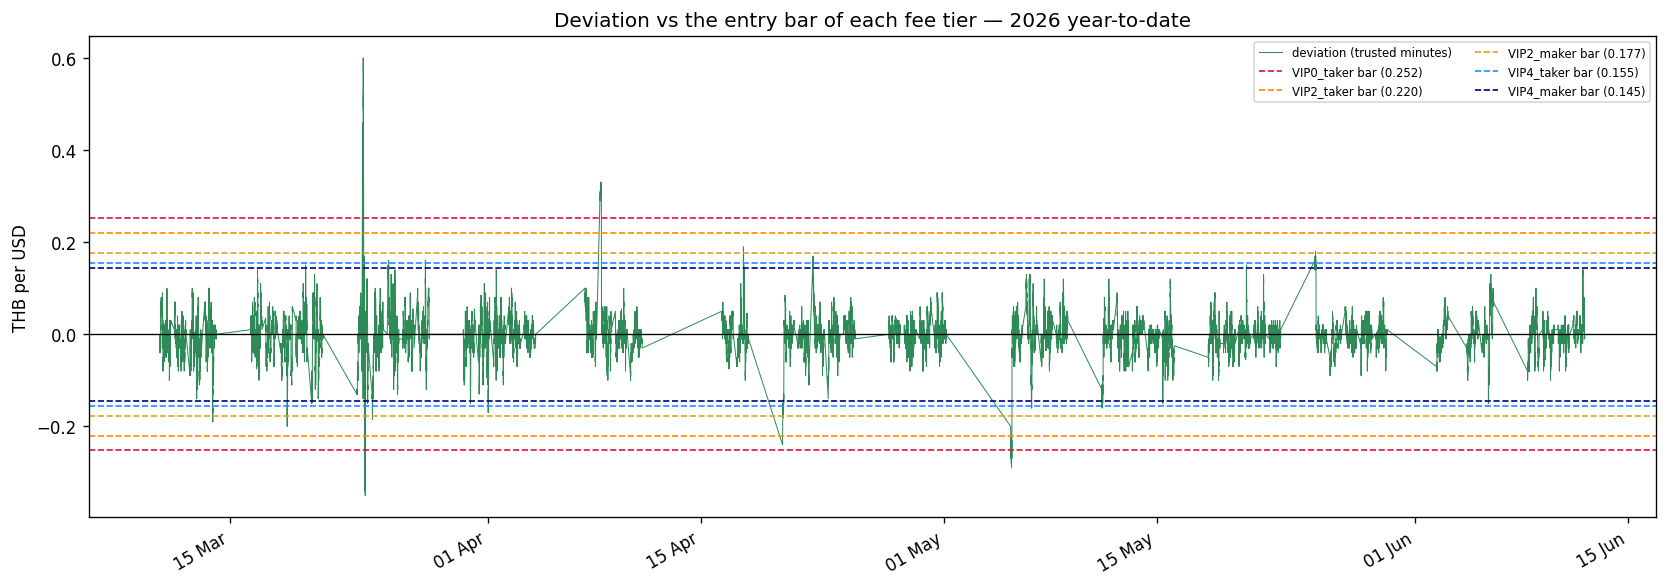

In [5]:
colors = {"VIP0_taker": "crimson", "VIP2_taker": "darkorange", "VIP2_maker": "goldenrod",
          "VIP4_taker": "dodgerblue", "VIP4_maker": "navy"}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fresh.index, fresh["dev"], lw=0.6, color="seagreen", label="deviation (trusted minutes)")
for name, sc in FEE_SCENARIOS.items():
    ax.axhline(sc["bar"], color=colors[name], ls="--", lw=1, label=f"{name} bar ({sc['bar']:.3f})")
    ax.axhline(-sc["bar"], color=colors[name], ls="--", lw=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Deviation vs the entry bar of each fee tier — {YEAR} year-to-date")
ax.set_ylabel("THB per USD")
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=14))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## Step 5 — The simulation: same rules, five fee tiers

1. **Flat?** deviation beyond the entry bar -> open the pair trade (either direction).
2. **In a trade?** deviation back inside one tick (0.01) -> close both legs.
3. One position at a time. P&L per contract = `(deviation captured - round trip) x 1,000`.

The *only* thing that changes between runs is the cost.

In [6]:
def run_backtest(data, rt_cost, entry_buffer=ENTRY_BUFFER_THB, exit_tol=EXIT_TOLERANCE_THB):
    position, trades = None, []
    for ts, dev in data["dev"].items():
        if position is None:
            if dev - rt_cost >= entry_buffer:
                position = {"side": "short_usdt_long_tfex", "entry_ts": ts, "entry_dev": dev}
            elif -dev - rt_cost >= entry_buffer:
                position = {"side": "long_usdt_short_tfex", "entry_ts": ts, "entry_dev": dev}
        elif abs(dev) <= exit_tol:
            pnl = (abs(position["entry_dev"]) - abs(dev)) - rt_cost
            trades.append({**position, "exit_ts": ts, "exit_dev": dev,
                           "hold_hours": (ts - position["entry_ts"]).total_seconds() / 3600,
                           "pnl_thb_per_contract": pnl * 1000})
            position = None
    return pd.DataFrame(trades)


results, summary_rows = {}, []
for name, sc in FEE_SCENARIOS.items():
    t = run_backtest(fresh, sc["round_trip"])
    results[name] = t
    summary_rows.append({"scenario": name, "round_trip": round(sc["round_trip"], 4),
                         "trades": len(t),
                         "win_rate": f"{(t.pnl_thb_per_contract > 0).mean():.0%}" if len(t) else "-",
                         "median_hold_h": round(t.hold_hours.median(), 1) if len(t) else "-",
                         "total_pnl_thb_per_contract": round(t.pnl_thb_per_contract.sum()) if len(t) else 0})
summary = pd.DataFrame(summary_rows).set_index("scenario")
display(summary)

,round_trip,trades,win_rate,median_hold_h,total_pnl_thb_per_contract
scenario,,,,,
VIP0_taker,0.2423,6,100%,1.0,686
VIP2_taker,0.2098,7,100%,1.0,781
VIP2_maker,0.1674,12,100%,1.4,1077
VIP4_taker,0.1449,19,100%,1.7,1377
VIP4_maker,0.1349,25,100%,1.6,1587


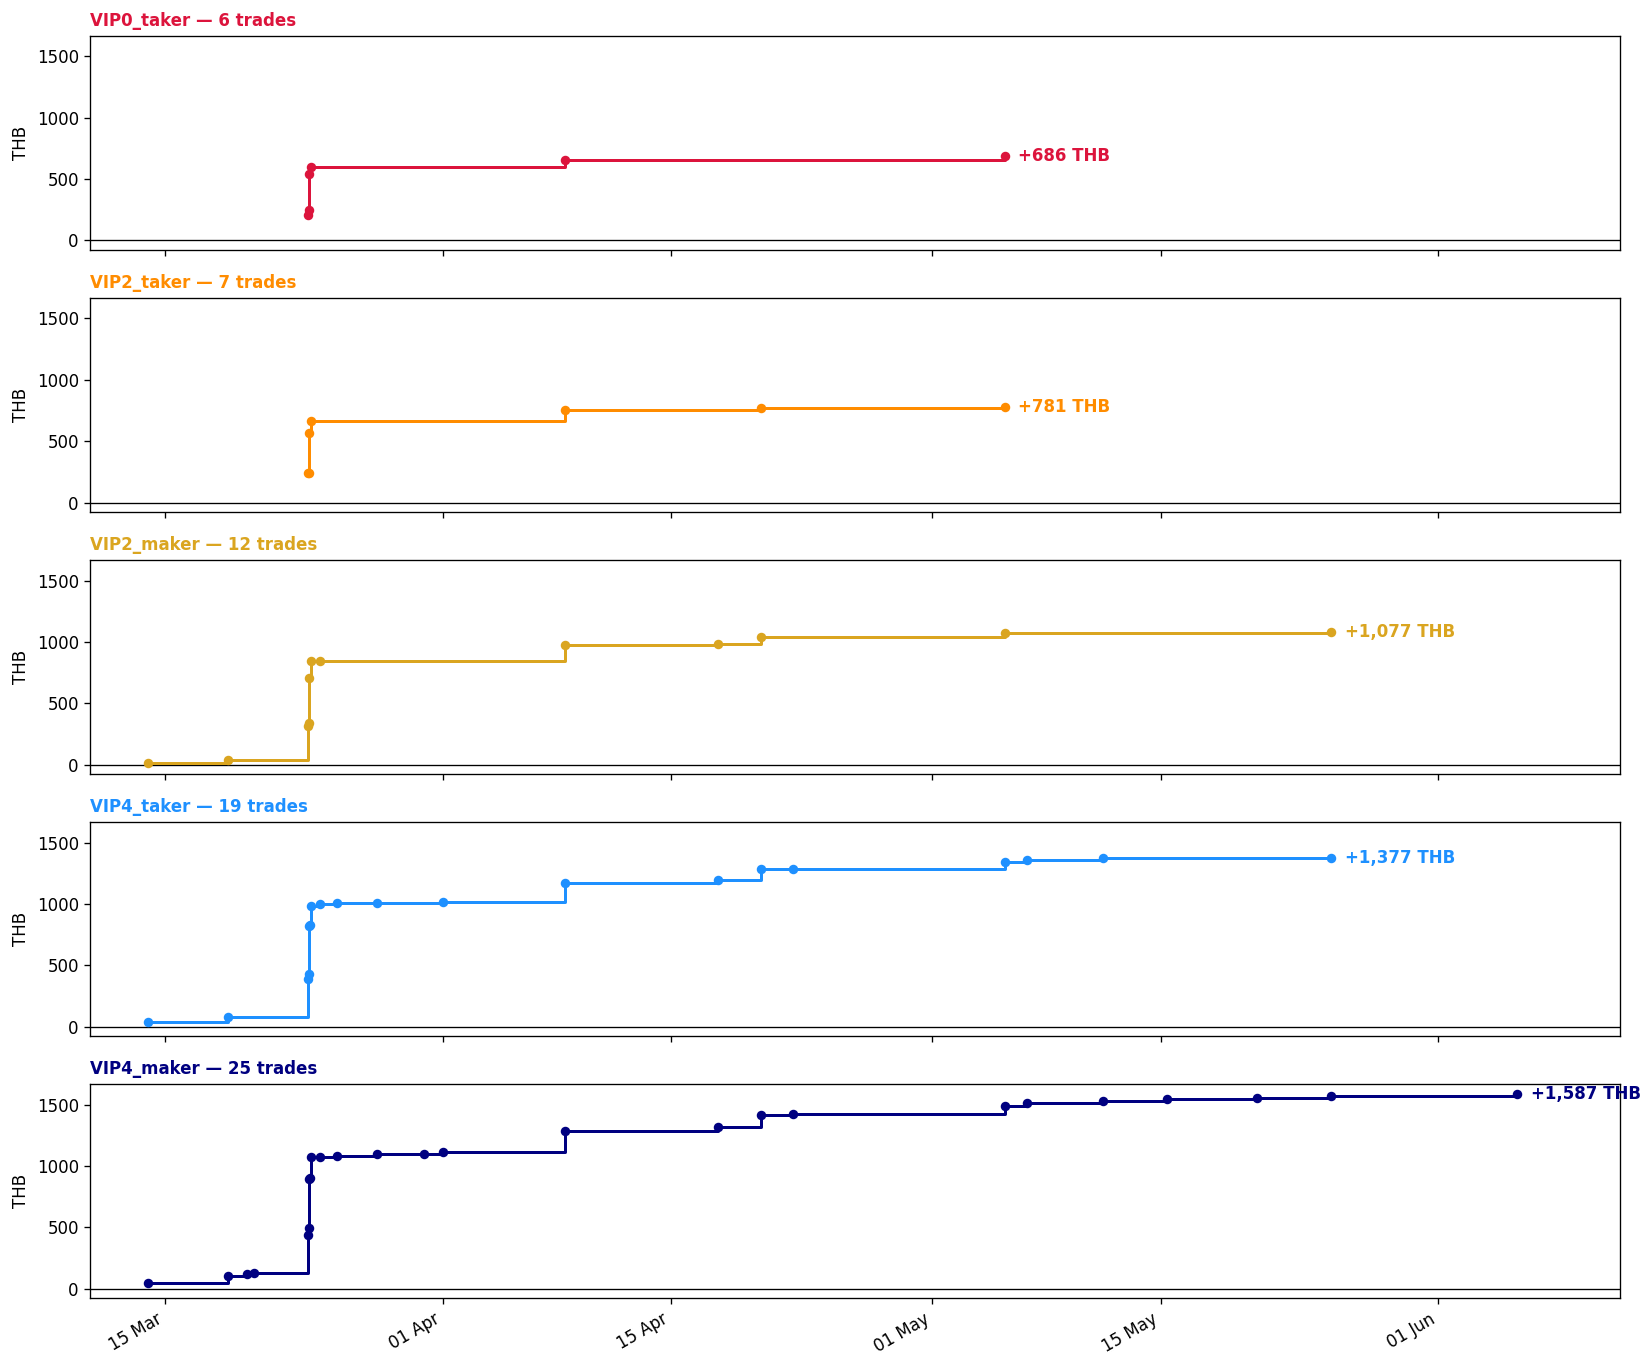

In [7]:
panels = list(colors.items())
window_start, window_end = fresh.index.min(), fresh.index.max()

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 2.3 * len(panels)),
                         sharex=True, sharey=True)
for ax, (name, color) in zip(axes, panels):
    t = results[name]
    ax.axhline(0, color="black", lw=0.8)
    if t.empty:
        ax.text(0.5, 0.55, "0 trades", transform=ax.transAxes,
                ha="center", fontsize=11, color="grey", style="italic")
        label = f"{name} — no trades"
    else:
        t = t.sort_values("exit_ts")
        cum = t.pnl_thb_per_contract.cumsum()
        ax.step(t.exit_ts, cum, where="post", lw=1.8, color=color)
        ax.scatter(t.exit_ts, cum, s=22, color=color, zorder=5)
        ax.annotate(f"{cum.iloc[-1]:+,.0f} THB", xy=(t.exit_ts.iloc[-1], cum.iloc[-1]),
                    xytext=(8, 0), textcoords="offset points", va="center",
                    fontsize=10, fontweight="bold", color=color)
        label = f"{name} — {len(t)} trades"
    ax.set_title(label, fontsize=10, loc="left", color=color, fontweight="bold")
    ax.set_ylabel("THB")
    ax.set_xlim(window_start, window_end)

axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=6, maxticks=14))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## Step 6 — The chart you asked for: RETURN in percent

THB profit means nothing without asking *"on how much money?"* Per contract you must park:

```text
capital = 1,000 USD on Binance (spot - no leverage)   ~ avg price x 1,000 THB
        + TFEX initial margin (assumption: 1,200 THB - ask your broker)
        + 10% cash buffer
```

Top: each tier's window return as % of that capital. Bottom: the equity curve of the best
tier, in % — **this is what the strategy returns if it works**.

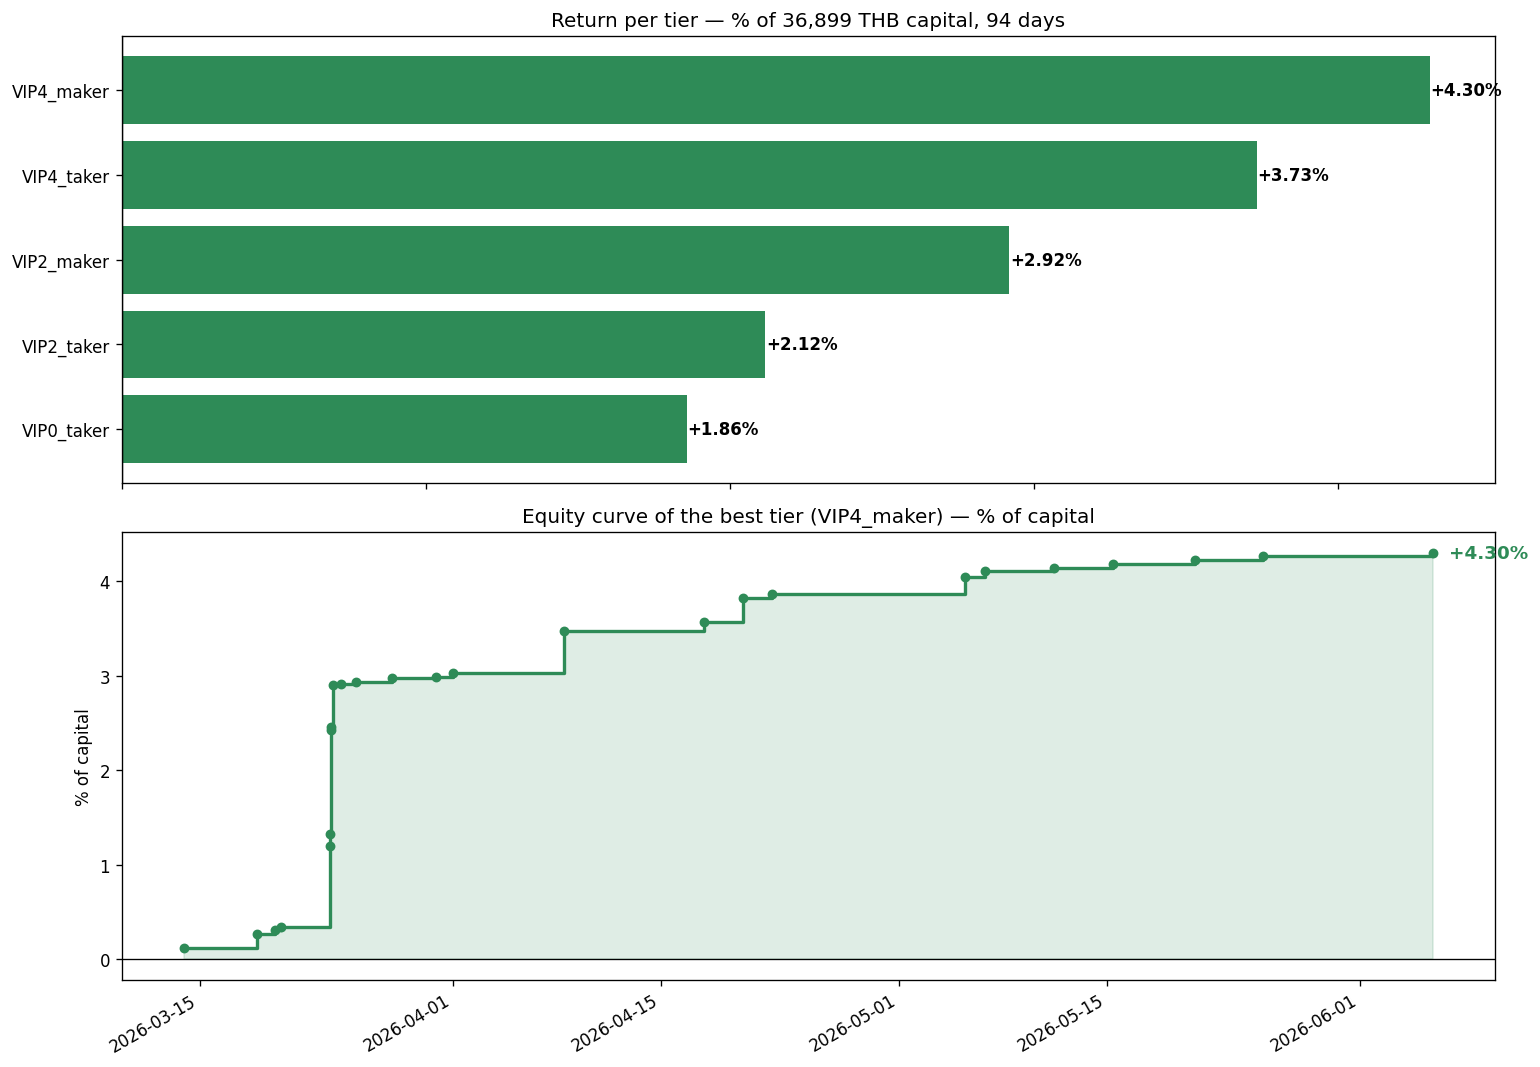

Best tier: VIP4_maker -> +1,587 THB = +4.30% on 36,899 THB in 94 days
Reminder: win rate 100% is BY CONSTRUCTION (we only exit when the gap is gone);
the risk is the WAIT (capital locked while the gap stays open) and quiet windows.


In [8]:
IM_TFEX_USD_THB = 1_200
BUFFER_RATIO = 0.10
binance_leg = avg_price * 1000
capital = binance_leg + IM_TFEX_USD_THB + binance_leg * BUFFER_RATIO
days = (window_end - window_start).days + 1

pnl_thb = summary["total_pnl_thb_per_contract"].astype(float)
pnl_pct = (pnl_thb / capital * 100).sort_values()
best_name = pnl_pct.idxmax()

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

bar_colors = ["seagreen" if v > 0 else "lightgrey" for v in pnl_pct]
bars = axes[0].barh(pnl_pct.index, pnl_pct.values, color=bar_colors)
for bar, v in zip(bars, pnl_pct.values):
    axes[0].text(bar.get_width() + (0.002 if v >= 0 else -0.002),
                 bar.get_y() + bar.get_height() / 2, f"{v:+.2f}%",
                 va="center", ha="left" if v >= 0 else "right", fontsize=10, fontweight="bold")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title(f"Return per tier — % of {capital:,.0f} THB capital, {days} days")
axes[0].set_xlabel("% of capital")

t = results[best_name]
if t.empty:
    axes[1].text(0.5, 0.5, "best tier had no trades", transform=axes[1].transAxes,
                 ha="center", color="grey", style="italic")
else:
    t = t.sort_values("exit_ts")
    cum_pct = t.pnl_thb_per_contract.cumsum() / capital * 100
    axes[1].step(t.exit_ts, cum_pct, where="post", color="seagreen", lw=2)
    axes[1].fill_between(t.exit_ts, 0, cum_pct, step="post", alpha=0.15, color="seagreen")
    axes[1].scatter(t.exit_ts, cum_pct, s=24, color="seagreen", zorder=5)
    axes[1].annotate(f"{cum_pct.iloc[-1]:+.2f}%", xy=(t.exit_ts.iloc[-1], cum_pct.iloc[-1]),
                     xytext=(10, 0), textcoords="offset points", va="center",
                     fontsize=11, fontweight="bold", color="seagreen")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"Equity curve of the best tier ({best_name}) — % of capital")
axes[1].set_ylabel("% of capital")
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

print(f"Best tier: {best_name} -> {pnl_thb[best_name]:+,.0f} THB = {pnl_pct.max():+.2f}% "
      f"on {capital:,.0f} THB in {days} days")
print("Reminder: win rate 100% is BY CONSTRUCTION (we only exit when the gap is gone);")
print("the risk is the WAIT (capital locked while the gap stays open) and quiet windows.")

## Step 7 — Can the strategy keep the VIP tier it needs?

The tier is rented, not owned: VIP 2 needs ≥ 500k USD and VIP 4 ≥ 3M USD of **30-day**
Binance volume, recalculated daily. One round trip of 1 contract = 2,000 USD of volume.
Our window is longer than 30 days, so the fair comparison is the volume the strategy
generates **per 30 days on average**.

In [9]:
window_days = max((window_end - window_start).days + 1, 1)
vol_rows = []
for name in ["VIP2_taker", "VIP2_maker", "VIP4_taker", "VIP4_maker"]:
    req = VIP_VOLUME_REQ_USD[name.split("_")[0]]
    n = len(results[name])
    vol_30d = n * 2000 * 30 / window_days
    vol_rows.append({"scenario": name, "trades": n,
                     "volume_whole_window_usd": f"{n * 2000:,}",
                     "avg_volume_per_30d_usd": f"{vol_30d:,.0f}",
                     "volume_needed_per_30d_usd": f"{req:,}",
                     "verdict": "self-sustaining" if vol_30d >= req
                                else ("no trades" if n == 0 else "needs other volume")})
display(pd.DataFrame(vol_rows).set_index("scenario"))

,trades,volume_whole_window_usd,avg_volume_per_30d_usd,volume_needed_per_30d_usd,verdict
scenario,,,,,
VIP2_taker,7,"14,000","4,468","500,000",needs other volume
VIP2_maker,12,"24,000","7,660","500,000",needs other volume
VIP4_taker,19,"38,000","12,128","3,000,000",needs other volume
VIP4_maker,25,"50,000","15,957","3,000,000",needs other volume


## Honest limits — read before believing the percentages

1. **The "year-to-date" is really "since the contract existed."** Settrade's API deletes
   expired contracts and `USDM26` only traded from 10 Mar, so Jan-Feb are invisible here.
   If you want a true full-year study you must collect the data yourself while it exists —
   that is exactly what the Railway logger does for the bid/ask version
   (`vip_fee_strategy_real_bidask.ipynb`).
2. **Candles + a 60m reference are approximations.** Real decisions need real bid/ask:
   `usdtthb_spread_tutorial.ipynb` and `vip_fee_strategy_real_bidask.ipynb` run the same
   strategy on your Railway logger data.
3. **Maker rows assume your limit order fills** — at the exact moment the gap is widest,
   price is running away from your quote. Truth lives between maker and taker rows.
4. **One contract held for months has carry.** The June future trades a touch above spot
   and that premium decays; the 4h rolling median absorbs it, but a real position held
   across months would also pay roll/funding effects this simulation ignores.
5. **A quiet window can show 0% at every tier.** That is the honest result; the opportunity
   is episodic (spike days), so keep the logger running and re-run.
6. **The capital number is an assumption** (TFEX margin changes; ask your broker). The %
   chart updates automatically when you fix it.

## Summary

- The strategy is three lines: spread, typical spread (4h median), deviation. **Trade when
  the deviation beats all costs, close when it is gone.**
- The fee tier decides everything: the entry bar drops ~0.03 THB/USD per tier step, and the
  return-% chart shows exactly what that is worth on your capital.
- Tick size (0.01 THB = 10 THB/contract) is the price step, **not** a fee.
- The VIP tier itself costs volume — check Step 7 before assuming the better fee is yours:
  on a months-long window the requirement is per *30 days*, which is even harder to keep.
- And the meta-lesson of this edition: **exchange APIs forget.** Expired TFEX contracts
  vanish, so the only way to study a full year of this market is to log it yourself.

### Sources
[Binance TH fees](https://www.binance.th/en/faq/spot-trading/4900a0792af24f5e853e2373b84f94e7) ·
[Settrade `get_candlestick`](https://developer.settrade.com/open-api/api-reference/reference/sdkv2/python/market-historical-data/2_getCandlestick) ·
[TFEX USD futures spec](https://www.ylgfutures.co.th/en/futures/tfex/currency/usdthb-futures) ·
30-day edition: `usdthb_fee_tiers_simple.ipynb` · z-score edition: `usdthb_zscore_fees_tutorial.ipynb`